# BOAMP Linkage Error Analysis

## tl;dr

This notebook diagnoses why the current baseline linkage methods are not yet good enough for survival analysis. It converts predictions into error types, creates review tables for false positives and false negatives, and saves visual evidence for reports.


## Context & Methods

The current best baseline is `M3_weighted_rule_score`, but locked-test precision@1 is only 0.25. This notebook explains that result by inspecting top-1 predictions, score distributions, candidate-pair evidence, and subgroup behavior.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 220)
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data/processed/boamp_grand_ouest/linkage_baseline_predictions.parquet").exists():
            return candidate
    return Path.cwd()

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data/processed/boamp_grand_ouest"
FIGURE_DIR = PROCESSED_DIR / "figures" / "linkage_error_analysis"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_PATH = PROCESSED_DIR / "linkage_baseline_predictions.parquet"
PAIRS_PATH = PROCESSED_DIR / "renewal_candidate_pairs.parquet"
ANCHOR_PATH = PROCESSED_DIR / "reference_anchor_episodes.parquet"
LINKS_PATH = PROCESSED_DIR / "reference_successor_links.parquet"
CONFIG_PATH = PROCESSED_DIR / "linkage_best_baseline_config.json"
ERROR_CASES_PATH = PROCESSED_DIR / "linkage_error_cases.csv"
FALSE_POSITIVE_PATH = PROCESSED_DIR / "linkage_false_positive_review_cases.csv"
FALSE_NEGATIVE_PATH = PROCESSED_DIR / "linkage_false_negative_review_cases.csv"
SUMMARY_PATH = PROCESSED_DIR / "linkage_error_analysis_summary.json"

print(PROJECT_ROOT)


/home/senghakrou/project-gigalis


## Data

### 1. Load Predictions, Candidate Pairs, And Reference Truth


In [2]:
def parse_json_list(value) -> list:
    if value is None or pd.isna(value):
        return []
    text = str(value).strip()
    if text == "":
        return []
    try:
        parsed = json.loads(text)
    except Exception:
        return []
    return parsed if isinstance(parsed, list) else [parsed]

predictions = pd.read_parquet(PREDICTIONS_PATH)
pairs = pd.read_parquet(PAIRS_PATH)
anchors = pd.read_parquet(ANCHOR_PATH)
links = pd.read_parquet(LINKS_PATH)
config = json.loads(CONFIG_PATH.read_text())
best_algorithm = config["best_algorithm_by_locked_precision_then_recall5"]
best_config = config["best_algorithm_config"]

best_predictions = predictions[predictions["algorithm"].eq(best_algorithm)].copy()
best_predictions["predicted_idwebs"] = best_predictions["predicted_idwebs_json"].map(parse_json_list)
best_predictions["true_successor_idwebs"] = best_predictions["true_successor_idwebs_json"].map(parse_json_list)
best_predictions["predicted_any"] = best_predictions["predicted_idwebs"].map(bool)
best_predictions["has_true_successor"] = best_predictions["true_successor_idwebs"].map(bool)
best_predictions["top1_predicted_idweb"] = best_predictions["top1_predicted_idweb"].fillna("").astype(str)

print("Best algorithm:", best_algorithm, best_config)
print(best_predictions.shape, pairs.shape, anchors.shape, links.shape)


Best algorithm: M3_weighted_rule_score {'weights': 'balanced', 'threshold': 65, 'top_k': 5}
(94, 14) (8095, 41) (120, 33) (28, 17)


### 2. Reconstruct Best Baseline Scores For Evidence Inspection


In [3]:
WEIGHT_PRESETS = {
    "balanced": {"buyer": 0.35, "text": 0.25, "cpv": 0.20, "time": 0.15, "geo": 0.05},
    "precision_buyer": {"buyer": 0.45, "text": 0.20, "cpv": 0.20, "time": 0.10, "geo": 0.05},
    "text_heavy": {"buyer": 0.30, "text": 0.35, "cpv": 0.15, "time": 0.15, "geo": 0.05},
}

def add_weighted_score(frame: pd.DataFrame, weights: dict, score_name: str) -> pd.DataFrame:
    tmp = frame.copy()
    buyer_score = tmp["buyer_match_type"].map({"siren": 1.0, "normalized_name": 0.9, "fuzzy_name": 0.7, "token_overlap": 0.6}).fillna(0)
    text_score = tmp[["word_tfidf_similarity", "char_ngram_tfidf_similarity"]].max(axis=1).fillna(0).clip(0, 1)
    cpv_score = tmp["cpv_overlap_score"].fillna(0).clip(0, 1)
    time_score = tmp["duration_gap_score"].fillna(0).clip(0, 1)
    geo_score = tmp["same_region"].astype(bool).astype(float)
    tmp["buyer_score_component"] = buyer_score
    tmp["text_score_component"] = text_score
    tmp["cpv_score_component"] = cpv_score
    tmp["time_score_component"] = time_score
    tmp["geo_score_component"] = geo_score
    tmp[score_name] = 100 * (weights["buyer"] * buyer_score + weights["text"] * text_score + weights["cpv"] * cpv_score + weights["time"] * time_score + weights["geo"] * geo_score)
    return tmp

scored_pairs = add_weighted_score(pairs, WEIGHT_PRESETS[best_config["weights"]], "best_weighted_score")
top1_evidence = (
    best_predictions[["sample_id", "benchmark_split", "anchor_episode_id", "final_outcome", "true_successor_idwebs", "predicted_idwebs", "predicted_any", "has_true_successor", "top1_predicted_idweb", "top1_correct", "top5_correct"]]
    .merge(scored_pairs, left_on=["sample_id", "top1_predicted_idweb"], right_on=["sample_id", "candidate_idweb"], how="left", suffixes=("", "_pair"))
)

def classify_error(row) -> str:
    if row["has_true_successor"] and row["top1_correct"]:
        return "true_positive_top1"
    if row["has_true_successor"] and row["top5_correct"]:
        return "true_successor_in_top5_not_top1"
    if row["has_true_successor"] and row["predicted_any"]:
        return "false_negative_wrong_link"
    if row["has_true_successor"] and not row["predicted_any"]:
        return "false_negative_no_link"
    if not row["has_true_successor"] and row["predicted_any"]:
        return "false_positive_no_successor"
    return "true_negative_no_link"

top1_evidence["error_type"] = top1_evidence.apply(classify_error, axis=1)
print(top1_evidence["error_type"].value_counts().to_string())


error_type
true_negative_no_link              39
false_positive_no_successor        31
true_positive_top1                 14
false_negative_wrong_link           5
true_successor_in_top5_not_top1     4
false_negative_no_link              1


## Results

### 3. Error Type Summary


,benchmark_split,error_type,anchors
3,LOCKED_TEST,true_negative_no_link,33
2,LOCKED_TEST,false_positive_no_successor,26
4,LOCKED_TEST,true_positive_top1,11
1,LOCKED_TEST,false_negative_wrong_link,5
5,LOCKED_TEST,true_successor_in_top5_not_top1,2
0,LOCKED_TEST,false_negative_no_link,1
7,PILOT_DEVELOPMENT,true_negative_no_link,6
6,PILOT_DEVELOPMENT,false_positive_no_successor,5
8,PILOT_DEVELOPMENT,true_positive_top1,3
9,PILOT_DEVELOPMENT,true_successor_in_top5_not_top1,2


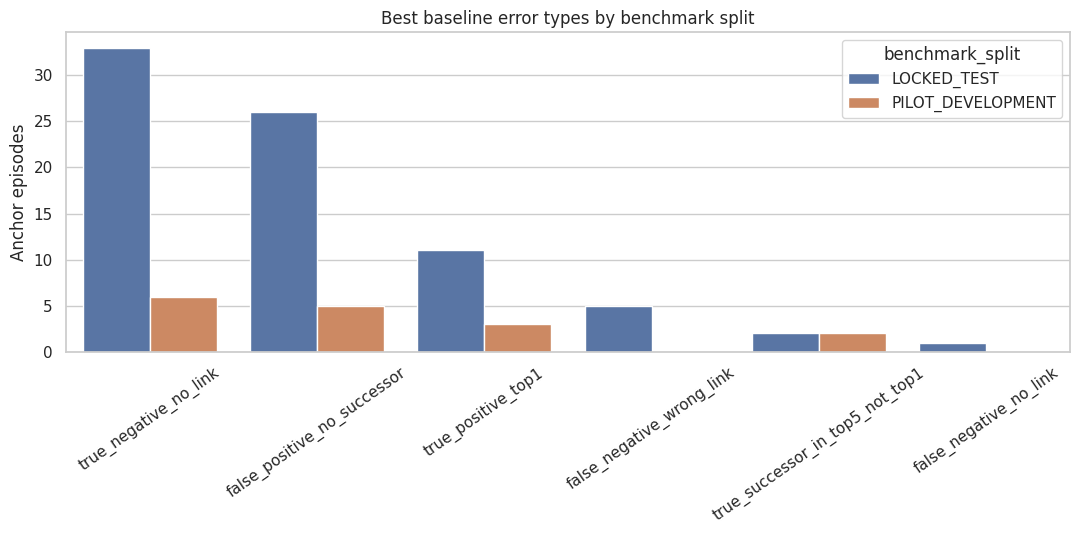

In [4]:
error_summary = (
    top1_evidence.groupby(["benchmark_split", "error_type"])
    .size()
    .reset_index(name="anchors")
    .sort_values(["benchmark_split", "anchors"], ascending=[True, False])
)
display(error_summary)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=error_summary, x="error_type", y="anchors", hue="benchmark_split", ax=ax)
ax.set_title("Best baseline error types by benchmark split")
ax.set_xlabel("")
ax.set_ylabel("Anchor episodes")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
path_error_types = FIGURE_DIR / "01_error_types_by_split.png"
fig.savefig(path_error_types, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()


### 4. Evidence Feature Distributions By Error Type


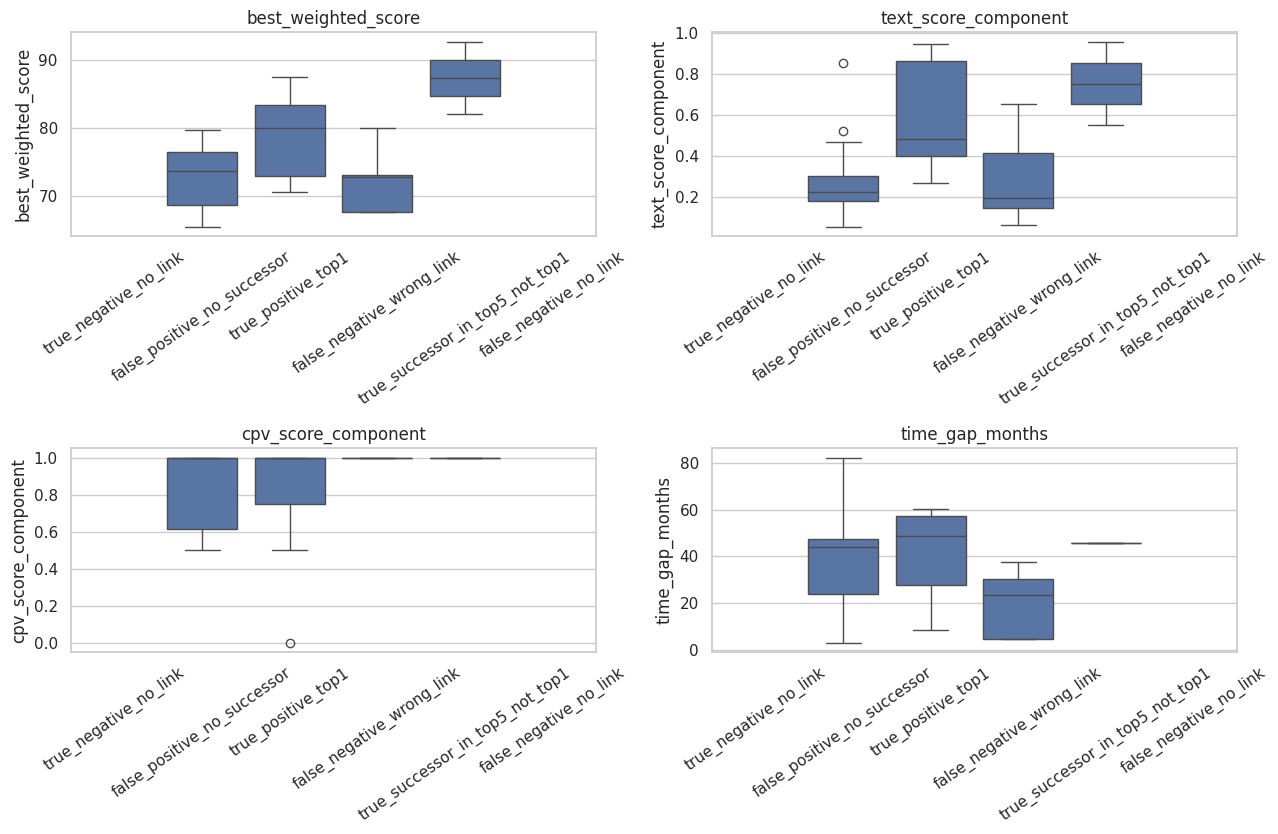

,best_weighted_score,buyer_score_component,text_score_component,cpv_score_component,time_score_component,buyer_name_similarity,word_tfidf_similarity,char_ngram_tfidf_similarity,time_gap_months
error_type,,,,,,,,,
false_negative_no_link,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
false_negative_wrong_link,72.833,0.9,0.196,1.0,0.629,1.0,0.139,0.196,23.4
false_positive_no_successor,73.687,0.9,0.225,1.0,0.888,1.0,0.093,0.225,43.9
true_negative_no_link,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_positive_top1,80.013,0.9,0.483,1.0,0.776,1.0,0.422,0.483,48.8
true_successor_in_top5_not_top1,87.443,0.9,0.754,1.0,0.807,1.0,0.692,0.754,45.7


In [5]:
feature_cols = ["best_weighted_score", "buyer_score_component", "text_score_component", "cpv_score_component", "time_score_component", "buyer_name_similarity", "word_tfidf_similarity", "char_ngram_tfidf_similarity", "time_gap_months"]
plot_frame = top1_evidence[top1_evidence["benchmark_split"].eq("LOCKED_TEST")].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for ax, col in zip(axes.ravel(), ["best_weighted_score", "text_score_component", "cpv_score_component", "time_gap_months"]):
    sns.boxplot(data=plot_frame, x="error_type", y=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")
fig.tight_layout()
path_feature_boxes = FIGURE_DIR / "02_feature_distributions_by_error_type.png"
fig.savefig(path_feature_boxes, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

summary_features = plot_frame.groupby("error_type")[feature_cols].median(numeric_only=True).round(3)
display(summary_features)


### 5. False Positive Review Cases


In [6]:
review_columns = [
    "sample_id", "benchmark_split", "anchor_episode_id", "final_outcome", "final_confidence", "anchor_award_notice_date", "anchor_expected_end_date",
    "anchor_buyer_name", "anchor_theme", "anchor_text_normalized", "top1_predicted_idweb", "candidate_dateparution", "candidate_buyer_name",
    "candidate_primary_cpv_prefix2", "candidate_technology_segment", "candidate_text_normalized", "url_avis", "time_gap_months", "buyer_match_type",
    "buyer_name_similarity", "buyer_token_overlap", "same_cpv_prefix", "cpv_overlap_score", "same_theme", "word_tfidf_similarity",
    "char_ngram_tfidf_similarity", "duration_gap_score", "best_weighted_score", "error_type"
]
false_positive_cases = top1_evidence[top1_evidence["error_type"].eq("false_positive_no_successor")].copy()
false_positive_cases = false_positive_cases[[c for c in review_columns if c in false_positive_cases.columns]].sort_values("best_weighted_score", ascending=False)
false_positive_cases.to_csv(FALSE_POSITIVE_PATH, index=False, encoding="utf-8")
display(false_positive_cases.head(15))
print(FALSE_POSITIVE_PATH)


,sample_id,benchmark_split,anchor_episode_id,final_outcome,anchor_award_notice_date,anchor_expected_end_date,anchor_buyer_name,anchor_theme,anchor_text_normalized,top1_predicted_idweb,candidate_dateparution,candidate_buyer_name,candidate_primary_cpv_prefix2,candidate_technology_segment,candidate_text_normalized,url_avis,time_gap_months,buyer_match_type,buyer_name_similarity,buyer_token_overlap,same_cpv_prefix,cpv_overlap_score,same_theme,word_tfidf_similarity,char_ngram_tfidf_similarity,duration_gap_score,best_weighted_score,error_type
28,RV-039,LOCKED_TEST,EP-6d1f6e6f718b1cc7,NO_OBSERVED_SUCCESSOR_IN_SCOPE,2019-04-12,,CENTRE HOSPITALIER UNIVERSITAIRE,CPV-48,acquisition et mise en oeuvre de modules complementaires et prestations concernant les applications du si acquisition et mise en oeuvre de modules complementaires et prestations concernant les applications du systeme...,23-144948,2023-10-17,CENTRE HOSPITALIER UNIVERSITAIRE,48,software,acquisition et maintenance d une solution de gestion des preparations pharmaceutiques,https://www.boamp.fr/pages/avis/?q=idweb:23-144948,54.2,siren,1.000000,1.0,True,1.0,True,0.090733,0.263431,0.870548,79.643989,false_positive_no_successor
65,RV-086,LOCKED_TEST,EP-df17711a48398e77,NO_OBSERVED_SUCCESSOR_IN_SCOPE,2015-06-29,,Côtes d'Armor Habitat,CPV-48,fourniture installation et maintenance d une ged pour le compte des cotes d armor habitat a ploufragan fourniture installation et maintenance d une g e d fourniture installation et maintenance d une g e d pour cotes ...,15-174531,2015-11-19,Côtes d'Armor Habitat,48,software,fourniture installation et maintenance d une ged a ploufragan,https://www.boamp.fr/pages/avis/?q=idweb:15-174531,4.7,normalized_name,1.000000,1.0,True,1.0,True,0.744489,0.853790,0.097945,79.313935,false_positive_no_successor
27,RV-038,LOCKED_TEST,EP-afc4aec9b670f309,NO_OBSERVED_SUCCESSOR_IN_SCOPE,2018-08-19,,Nantes Métropole,CPV-48,mise en oeuvre d une solution de gestion et de suivi des declarations de travaux et des recepisses associes mise en uvre d une solution de gestion et de suivi des declarations de travaux et des recepisses associes ma...,22-142509,2022-10-24,Nantes Métropole,48,software,accord cadre relatif a l acquisition l hebergement et la maintenance d un logiciel de gestion des collections vegetales pour le compte du groupement de commandes informatiques,https://www.boamp.fr/pages/avis/?q=idweb:22-142509,50.2,normalized_name,1.000000,1.0,True,1.0,True,0.199086,0.335323,0.954110,79.194709,false_positive_no_successor
62,RV-083,LOCKED_TEST,EP-c59f48fe0bca7d74,NO_OBSERVED_SUCCESSOR_IN_SCOPE,2017-01-02,,Rennes Métropole,CPV-72,acquisition et maintenance d un systeme informatise de gestion et de publication des collections des musees de bretagne et des beaux arts a rennes acquisition et maintenance d un systeme informatise de gestion et de ...,21-15601,2021-02-03,Rennes Métropole,72,it_services,acquisition mise en uvre et maintenance d un logiciel de gestion des stocks,https://www.boamp.fr/pages/avis/?q=idweb:21-15601,49.1,normalized_name,1.000000,1.0,True,1.0,True,0.168150,0.314937,0.977397,79.034395,false_positive_no_successor
74,RV-097,LOCKED_TEST,EP-861c31513037f7b6,NO_OBSERVED_SUCCESSOR_IN_SCOPE,2020-01-31,,DEPARTEMENT DE LA MAYENNE,CPV-72,prestations de maintenance et d assistance pour le logiciel astre gf accord cadre avec minimum et maximum passe en application des articles r2162 1 a r2162 6 du code de la commande publique il donnera lieu a l emissi...,23-168051,2023-12-01,DEPARTEMENT DE LA MAYENNE,72,it_services,acquisition et mise en oeuvre d une application mobile,https://www.boamp.fr/pages/avis/?q=idweb:23-168051,46.0,siren,1.000000,1.0,True,1.0,True,0.074400,0.163237,0.958904,78.464490,false_positive_no_successor
93,RV-120,LOCKED_TEST,EP-c43e3c1bc71270ca,NO_OBSERVED_SUCCESSOR_IN_SCOPE,2019-03-08,,CU AGL HAVRAISE CANT CRIQUETOT ESNEVAL,CPV-72,refonte informatique du reseau d alerte a la population de la codah refonte informatique et logicielle de la super

/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/linkage_false_positive_review_cases.csv


### 6. False Negative And Missed-Ranking Review Cases


In [7]:
false_negative_cases = top1_evidence[top1_evidence["error_type"].isin(["false_negative_wrong_link", "false_negative_no_link", "true_successor_in_top5_not_top1"])].copy()
false_negative_cases["true_successor_idwebs_json"] = false_negative_cases["true_successor_idwebs"].map(lambda values: json.dumps(values, ensure_ascii=False))
false_negative_cases["predicted_idwebs_json"] = false_negative_cases["predicted_idwebs"].map(lambda values: json.dumps(values, ensure_ascii=False))
false_negative_cases = false_negative_cases[[c for c in ["sample_id", "benchmark_split", "anchor_episode_id", "final_outcome", "anchor_award_notice_date", "anchor_buyer_name", "anchor_theme", "anchor_text_normalized", "true_successor_idwebs_json", "predicted_idwebs_json", "top1_predicted_idweb", "candidate_dateparution", "candidate_buyer_name", "candidate_text_normalized", "best_weighted_score", "word_tfidf_similarity", "char_ngram_tfidf_similarity", "cpv_overlap_score", "duration_gap_score", "error_type"] if c in false_negative_cases.columns]].sort_values(["benchmark_split", "error_type", "sample_id"])
false_negative_cases.to_csv(FALSE_NEGATIVE_PATH, index=False, encoding="utf-8")
display(false_negative_cases.head(20))
print(FALSE_NEGATIVE_PATH)


,sample_id,benchmark_split,anchor_episode_id,final_outcome,anchor_award_notice_date,anchor_buyer_name,anchor_theme,anchor_text_normalized,true_successor_idwebs_json,predicted_idwebs_json,top1_predicted_idweb,candidate_dateparution,candidate_buyer_name,candidate_text_normalized,best_weighted_score,word_tfidf_similarity,char_ngram_tfidf_similarity,cpv_overlap_score,duration_gap_score,error_type
87,RV-114,LOCKED_TEST,EP-c5dbe75a246e1eb7,OBSERVED_SUCCESSOR,NaN,NaN,NaN,NaN,"[""22-151258"", ""22-58440"", ""22-78991""]",[],,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,false_negative_no_link
24,RV-032,LOCKED_TEST,EP-4e4727b287bf8935,OBSERVED_SUCCESSOR,2016-04-30,Département de la Sarthe,CPV-32,fourniture pour le deploiement de reseaux tele informatiques dans les colleges publics de la sarthe au mans deploiement de reseaux tele informatiques dans les colleges publics de la sarthe marches a bons de commande ...,"[""20-150503"", ""21-63053""]","[""18-154770""]",18-154770,2018-11-05,DEPARTEMENT DE LA SARTHE,fourniture livraison installation et reparation d appareils de reception d enregistrement ou de reproduction du son et ou de l image pour les besoins des services du departement de l,67.519715,0.020990,0.063117,1.0,0.629452,false_negative_wrong_link
33,RV-046,LOCKED_TEST,EP-e95abb916548b865,OBSERVED_SUCCESSOR,2016-06-02,Ville de Caen,CPV-48,solution d achat et de controle de titres et abonnements de stationnement de surface dematerialises a caen solution d achat et de controle de titres et abonnements de stationnement de surface dematerialises solution ...,"[""19-166173"", ""20-71666""]","[""18-64863""]",18-64863,2018-05-14,Ville de Caen,fourniture hebergement et maintenance d une solution informatique de gestion des marches subsequents a l accord cadre impression de supports de communication et d information,67.523532,0.061890,0.148749,1.0,0.486986,false_negative_wrong_link
38,RV-051,LOCKED_TEST,EP-843eb3fcdf81f13f,OBSERVED_SUCCESSOR,2019-11-08,MARINE/DCSSF/ DSSFBrest,CPV-35,approvisionnement de rechanges de telephonie de marques diverses ou equivalents au profit des unites de la marine nationale approvisionnement de rechanges de telephonie de marques diverses ou equivalents au profit de...,"[""20-156116"", ""20-44434""]","[""20-43771"", ""20-48566"", ""20-43807"", ""20-38644"", ""20-43740""]",20-43771,2020-03-25,MARINE/DCSSF/ DSSFBrest,approvisionnement de rechanges de radionavigation de marques diverses ou equivalents au profit des batiments de la marine nationale,80.067945,0.414435,0.416690,1.0,0.876712,false_negative_wrong_link
39,RV-052,LOCKED_TEST,EP-d00a6c5610042d4f,OBSERVED_SUCCESSOR,2018-10-14,CCAS DE LA ROCHE-SUR-YON,CPV-35,evolution des appels infirmieres et des systemes d anti fugues des ehpad du centre communal d action sociale de la roche sur yon evolution des appels infirmieres et des systemes d anti fugues des ehpad du centre comm...,"[""25-98483""]","[""19-34719""]",19-34719,2019-03-07,CCAS DE LA ROCHE-SUR-YON,evolution des appels infirmieres et des systemes d anti fugues des ehpad du centre communal d action sociale de la roche sur yon,72.833382,0.653335,0.635258,1.0,0.000000,false_negative_wrong_link
54,RV-072,LOCKED_TEST,EP-a7005a531d605208,OBSERVED_SUCCESSOR,2015-10-20,Université d'Angers,CPV-32,materiels complementaires et prestations associees concernant la solution de wifi haut debit de l universite a angers materiels complementaires et prestations associees concernant la solution de wifi haut debit a l u...,"[""16-105924"", ""16-46830""]","[""18-167245"", ""19-10753"", ""18-146489"", ""19-190328"", ""20-1280""]",18-167245,2018-12-03,Université d'Angers,solution de podcasting et de diffusion en direct sur les campus de l universite d angers,73.107377,0.139308,0.195802,1.0,0.780822,false_negative_wrong_link
70,RV-093,LOCKED_TEST,EP-1bf59427055ac414,OBSERVED_SUCCESSOR,2018-06-02,SDIS 44,CPV-48,fourniture de logiciels bureautiques maintenance et prestations associees pour les besoins du sdis 44 fourniture de logiciels burea

/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/linkage_false_negative_review_cases.csv


### 7. Subgroup Error Diagnostics


,group,value,anchors,precision_at_1,recall_at_5,false_positive_rate_no_successor,coverage_rate
0,anchor_has_siren,False,67,0.259259,0.692308,0.277778,0.402985
1,anchor_has_siren,True,27,0.259259,0.818182,1.000000,1.000000
2,anchor_has_expected_end,False,71,0.225806,0.666667,0.338983,0.436620
3,anchor_has_expected_end,True,23,0.304348,0.833333,1.000000,1.000000
4,anchor_theme,CPV-32,19,0.368421,0.818182,1.000000,1.000000
5,anchor_theme,CPV-35,4,0.000000,0.000000,1.000000,1.000000
6,anchor_theme,CPV-48,17,0.235294,0.833333,1.000000,1.000000
7,anchor_theme,CPV-72,14,0.214286,1.000000,1.000000,1.000000
8,anchor_theme,unknown,40,0.000000,0.000000,0.000000,0.000000
9,benchmark_split,LOCKED_TEST,78,0.250000,0.684211,0.440678,0.564103


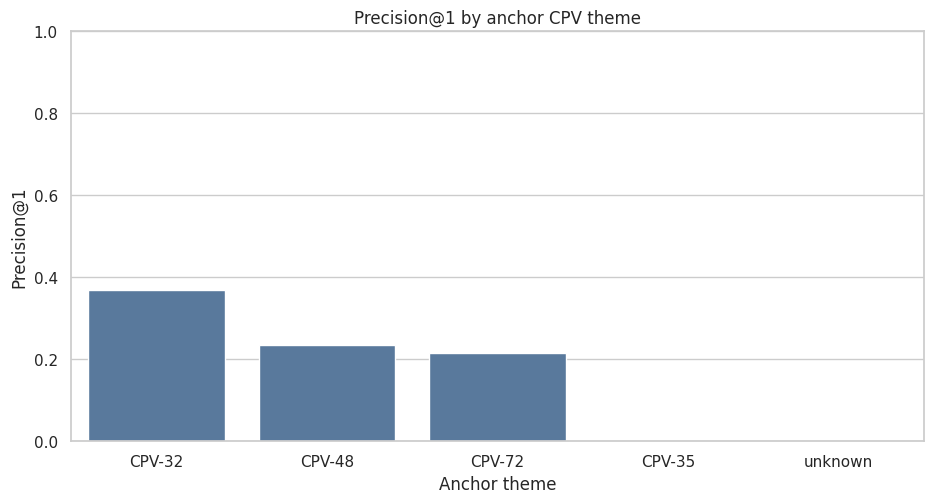

In [8]:
subgroup = top1_evidence.copy()
subgroup["anchor_has_siren"] = subgroup["anchor_buyer_siren"].fillna("").astype(str).str.len().gt(0)
subgroup["anchor_has_expected_end"] = subgroup["anchor_expected_end_date"].fillna("").astype(str).str.len().gt(0)
subgroup["anchor_theme"] = subgroup["anchor_theme"].fillna("unknown")
subgroup_metrics = []
for group_col in ["anchor_has_siren", "anchor_has_expected_end", "anchor_theme", "benchmark_split"]:
    for group_value, group in subgroup.groupby(group_col, dropna=False):
        predicted = group["predicted_any"].sum()
        positives = group["has_true_successor"].sum()
        no_successors = (~group["has_true_successor"]).sum()
        subgroup_metrics.append({
            "group": group_col,
            "value": str(group_value),
            "anchors": int(len(group)),
            "precision_at_1": float(group["top1_correct"].sum() / predicted) if predicted else 0.0,
            "recall_at_5": float(group["top5_correct"].sum() / positives) if positives else np.nan,
            "false_positive_rate_no_successor": float(((~group["has_true_successor"]) & group["predicted_any"]).sum() / no_successors) if no_successors else np.nan,
            "coverage_rate": float(group["predicted_any"].mean()) if len(group) else 0.0,
        })
subgroup_df = pd.DataFrame(subgroup_metrics)
display(subgroup_df)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
theme_plot = subgroup_df[subgroup_df["group"].eq("anchor_theme")].sort_values("precision_at_1", ascending=False)
sns.barplot(data=theme_plot, x="value", y="precision_at_1", color="#4E79A7", ax=ax)
ax.set_title("Precision@1 by anchor CPV theme")
ax.set_xlabel("Anchor theme")
ax.set_ylabel("Precision@1")
ax.set_ylim(0, 1)
fig.tight_layout()
path_theme_precision = FIGURE_DIR / "03_precision_by_anchor_theme.png"
fig.savefig(path_theme_precision, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()


### 8. Save Error Analysis Summary


In [9]:
top1_evidence[[c for c in review_columns if c in top1_evidence.columns]].to_csv(ERROR_CASES_PATH, index=False, encoding="utf-8")
summary = {
    "created_at": pd.Timestamp.now().isoformat(timespec="seconds"),
    "best_algorithm": best_algorithm,
    "best_config": best_config,
    "inputs": {"predictions": str(PREDICTIONS_PATH), "candidate_pairs": str(PAIRS_PATH)},
    "outputs": {
        "error_cases": str(ERROR_CASES_PATH),
        "false_positive_cases": str(FALSE_POSITIVE_PATH),
        "false_negative_cases": str(FALSE_NEGATIVE_PATH),
        "figure_dir": str(FIGURE_DIR),
    },
    "error_type_counts": {str(k): int(v) for k, v in top1_evidence["error_type"].value_counts().items()},
    "locked_test_error_type_counts": {str(k): int(v) for k, v in top1_evidence.loc[top1_evidence["benchmark_split"].eq("LOCKED_TEST"), "error_type"].value_counts().items()},
    "locked_test_feature_medians_by_error_type": summary_features.reset_index().to_dict(orient="records"),
    "main_diagnosis": "The current weighted baseline retrieves many true successors but over-links no-successor anchors. It should be made stricter before survival analysis.",
    "recommended_next_changes": [
        "Increase acceptance threshold or add a high-confidence threshold tier.",
        "Require stronger text similarity for no-duration or normalized-name-only matches.",
        "Penalize token-overlap/fuzzy buyer matches unless CPV and text evidence are both strong.",
        "Separate automatic links from manual-review candidates.",
    ],
}
SUMMARY_PATH.write_text(json.dumps(summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

manifest = pd.DataFrame([
    ["error_types_by_split", str(path_error_types)],
    ["feature_distributions_by_error_type", str(path_feature_boxes)],
    ["precision_by_anchor_theme", str(path_theme_precision)],
], columns=["artifact", "path"])
display(manifest)
assert ERROR_CASES_PATH.exists()
assert FALSE_POSITIVE_PATH.exists()
assert FALSE_NEGATIVE_PATH.exists()
assert SUMMARY_PATH.exists()


,artifact,path
0,error_types_by_split,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/linkage_error_analysis/01_error_types_by_split.png
1,feature_distributions_by_error_type,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/linkage_error_analysis/02_feature_distributions_by_error_type.png
2,precision_by_anchor_theme,/home/senghakrou/project-gigalis/data/processed/boamp_grand_ouest/figures/linkage_error_analysis/03_precision_by_anchor_theme.png


## Takeaways

The current baseline is a useful scaffold, but it should not feed survival analysis yet. The next implementation should use this error evidence to create stricter high-confidence acceptance rules and separate automatic links from manual-review candidates.
